Found 3 genes with zero variance.
Found 2 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 3 genes with zero variance.
Found 2 genes with zero variance.

=== TRAIN EVAL — LOPO + inner K-fold | ilr_inv-per-fold → mean (simplex) | NO PCA ===
Joint preprocess: CP10k + winsor(True, q=0.995) + asinh(True, c=1.0)
INNER folds up to 5 | Ridge α=0.01
Total train samples evaluated = 12
Avg RMSE = 0.0463
Per-CT RMSE:
T                0.0905
B                0.0650
Endothelial      0.0242
Fibroblast       0.0268
Plasmablast      0.0180
Myofibroblast    0.0290
NK               0.0764
Myeloid          0.0449
Mast             0.0423


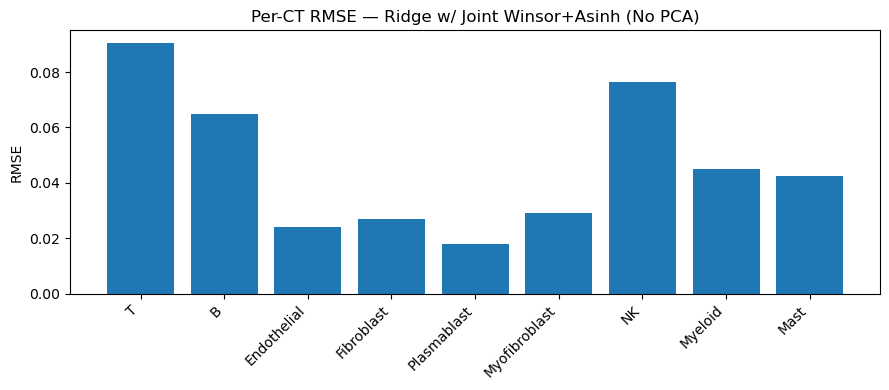


=== TEST PREDICTIONS (simplex, sum=1 per sample) ===
             T         B  Endothelial  Fibroblast  Plasmablast  Myofibroblast  \
s5_0  0.459365  0.134252     0.029378    0.061448     0.043832       0.077522   
s5_1  0.494905  0.134238     0.029411    0.078450     0.005863       0.058986   
s5_2  0.477760  0.176160     0.033438    0.044023     0.017971       0.075701   
s5_3  0.492408  0.125346     0.030041    0.075275     0.013532       0.065657   
s5_4  0.490713  0.161515     0.031516    0.064147     0.008664       0.063676   

            NK   Myeloid      Mast  
s5_0  0.141169  0.039044  0.013991  
s5_1  0.154464  0.026794  0.016890  
s5_2  0.102704  0.061122  0.011123  
s5_3  0.144140  0.034026  0.019573  
s5_4  0.118547  0.044730  0.016493  


In [1]:
# Jupyter cell: Joint-preproc bulk (train+test, no PCA) + LOPO(inner K) Ridge(ILR)
# Strategy: ilr_inv-per-fold → mean in simplex
from __future__ import annotations
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt, random, warnings
warnings.filterwarnings("ignore")
import sys
from pathlib import Path

# add project root to Python path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    
from scripts.decon import need_scanpy, preprocess_sc, cpm10k, winsorize_per_gene_pairwise, asinh_vst, parse_sample_from_bulk_col, pseudobulk_by_sample_ct, combat_on_pb, stratified_marker_union, helmert_basis, ilr, ilr_inv, simplex_proj
# ===== PATHS =====
AD_TRAIN_PATH   = r"../../Dataset/train_data/train_adata.h5ad"
AD_TEST_PATH    = r"../../Dataset/test_data/test_adata.h5ad"         # 不參與 marker（僅保留以備擴充）
BULK_TRAIN_PATH = r"../../Dataset/train_data/train_bulk.csv"         # genes × n_train
BULK_TEST_PATH  = r"../../Dataset/test_data/test_bulk.csv"           # genes × n_test
TRUE_PATH       = r"../../Dataset/train_data/train_bulk_trueprops.csv"
# ===== SETTINGS =====
CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
MARKER_TOPK_CT = 120
INNER_N_FOLDS  = 5
RIDGE_ALPHA    = 1e-2
SEED           = 42

# ---- Joint bulk preprocess (train+test together; NO PCA) ----
GLOBAL_WINSORIZE = True
GLOBAL_WINSOR_Q  = 0.995
GLOBAL_ASINH     = True
GLOBAL_ASINH_C   = 1.0

np.random.seed(SEED); random.seed(SEED)

# ===== load =====
sc = need_scanpy()
ad_tr = need_scanpy().read_h5ad(AD_TRAIN_PATH)
ad_te = need_scanpy().read_h5ad(AD_TEST_PATH)  # 不參與 marker；保留以備擴充
bulk_tr_raw = pd.read_csv(BULK_TRAIN_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
bulk_te_raw = pd.read_csv(BULK_TEST_PATH,  index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth       = pd.read_csv(TRUE_PATH, index_col=0)

# genes 對齊
genes = bulk_tr_raw.index.intersection(bulk_te_raw.index).astype(str)
bulk_tr_raw = bulk_tr_raw.loc[genes].astype(float)
bulk_te_raw = bulk_te_raw.loc[genes].astype(float)

# train sc preprocess（只用它選 marker）
preprocess_sc(ad_tr)

# ---- Joint bulk preprocess（CP10k + joint winsor + joint asinh；無 PCA）----
Btr = cpm10k(bulk_tr_raw.copy())
Bte = cpm10k(bulk_te_raw.copy())
if GLOBAL_WINSORIZE:
    Btr, Bte = winsorize_per_gene_pairwise(Btr, Bte, GLOBAL_WINSOR_Q)
if GLOBAL_ASINH:
    Btr = asinh_vst(Btr, GLOBAL_ASINH_C)
    Bte = asinh_vst(Bte, GLOBAL_ASINH_C)

B_all  = Btr   # genes × n_train
B_test = Bte   # genes × n_test

# train truth 對齊
for ct in TARGET_ORDER:
    if ct not in truth.index: truth.loc[ct] = 0.0
T_all = truth.loc[TARGET_ORDER, B_all.columns].T  # (n_train × K)

# sample -> patient（train）
if CELLTYPE_COL not in ad_tr.obs:
    if "cell_type" in ad_tr.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("missing cell-type column in train adata.obs")
if "Sample" not in ad_tr.obs or "Patient" not in ad_tr.obs:
    raise KeyError("train adata.obs needs 'Sample' and 'Patient'")

sample_to_patient = ad_tr.obs[["Sample","Patient"]].drop_duplicates().set_index("Sample")["Patient"].astype(str)
col_to_sample_train  = {c: parse_sample_from_bulk_col(c) for c in B_all.columns}
col_to_patient_train = {c: sample_to_patient.get(col_to_sample_train[c], "UNK") for c in B_all.columns}

keep_cols = [c for c in B_all.columns if col_to_patient_train[c]!="UNK" and c in T_all.index]
B_all = B_all[keep_cols]
T_all = T_all.loc[keep_cols]
patients_all = sorted({col_to_patient_train[c] for c in keep_cols})

# ILR basis
Kc = len(TARGET_ORDER); H = helmert_basis(Kc)

# ===== LOPO + inner K-fold（ilr_inv per fold → mean in simplex）=====
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge

# containers（train eval）
preds_by_sample_train: dict[str, list[np.ndarray]] = {}
truth_by_sample_train: dict[str, np.ndarray] = {}
patient_of_col_train: dict[str, str] = {}

# containers（real test）
bag_y_test_allfolds: dict[str, list[np.ndarray]] = {c: [] for c in B_test.columns}

for p_test in patients_all:
    test_cols_train_outer = [c for c in B_all.columns if col_to_patient_train[c]==p_test]
    if not test_cols_train_outer: continue

    others = [p for p in patients_all if p != p_test]
    if not others: continue

    K_inner = min(INNER_N_FOLDS, max(1, len(others)))
    kf = KFold(n_splits=K_inner, shuffle=True, random_state=SEED)
    others_arr = np.array(others)

    bag_y_train_outer: dict[str, list[np.ndarray]] = {c: [] for c in test_cols_train_outer}

    for in_id, (tr_mask, _) in enumerate(kf.split(others_arr), 1):
        in_tr_pats = set(others_arr[tr_mask].tolist())

        # 只用 inner-train 病人的 train 單細胞選 marker
        ad_inner = ad_tr[ad_tr.obs["Patient"].astype(str).isin(in_tr_pats)].copy()
        if ad_inner.n_obs < 10: continue

        # pseudobulk → ComBat（batch=Sample）
        pb_all = pseudobulk_by_sample_ct(ad_inner, CELLTYPE_COL, "Sample")
        pb_all = combat_on_pb(pb_all)

        # per-CT TopK union markers
        markers = stratified_marker_union(pb_all, topk_per_ct=MARKER_TOPK_CT, ct_order=TARGET_ORDER)

        # genes_used：落在 joint 前處理後的 train/test 交集
        genes_used = pd.Index(markers, dtype=str).intersection(B_all.index).intersection(B_test.index)
        if len(genes_used) < 20: continue

        # 準備矩陣（samples×genes_used），**不做 PCA**
        tr_cols_inner = [c for c in B_all.columns if col_to_patient_train[c] in in_tr_pats]
        if len(tr_cols_inner) < 2: continue

        X_tr_sg    = B_all.loc[genes_used, tr_cols_inner].T
        X_te_train = B_all.loc[genes_used, test_cols_train_outer].T
        X_te_real  = B_test.loc[genes_used, B_test.columns].T

        # Ridge on ILR
        y_in_tr = T_all.loc[tr_cols_inner].values
        z_in_tr = ilr(y_in_tr, H)
        model = MultiOutputRegressor(Ridge(alpha=RIDGE_ALPHA, random_state=SEED))
        model.fit(X_tr_sg, z_in_tr)

        # train outer-test
        z_pred_train = model.predict(X_te_train)
        y_pred_train = ilr_inv(z_pred_train, H)
        y_pred_train = np.vstack([simplex_proj(row) for row in y_pred_train])
        for i, col in enumerate(test_cols_train_outer):
            bag_y_train_outer[col].append(y_pred_train[i])

        # real test
        z_pred_real = model.predict(X_te_real)
        y_pred_real = ilr_inv(z_pred_real, H)
        y_pred_real = np.vstack([simplex_proj(row) for row in y_pred_real])
        for i, col in enumerate(B_test.columns):
            bag_y_test_allfolds[col].append(y_pred_real[i])

    # 此 outer 的 train 外測聚合
    for col in test_cols_train_outer:
        truth_by_sample_train[col] = T_all.loc[col].values
        patient_of_col_train[col]  = p_test
        if len(bag_y_train_outer[col]) > 0:
            y_mean = simplex_proj(np.mean(np.vstack(bag_y_train_outer[col]), axis=0))
        else:
            y_mean = np.ones(Kc)/Kc
        preds_by_sample_train.setdefault(col, []).append(y_mean)

# ===== 訓練集評估（train outer-test）=====
cols_eval = sorted(truth_by_sample_train.keys())
Y_true = np.vstack([truth_by_sample_train[c] for c in cols_eval])
Y_pred = np.vstack([simplex_proj(np.vstack(preds_by_sample_train[c]).mean(axis=0)) for c in cols_eval])

rmse_ct = np.sqrt(((Y_pred - Y_true)**2).mean(axis=0))
avg_rmse = float(rmse_ct.mean()); per_ct = pd.Series(rmse_ct, index=TARGET_ORDER)

print("\n=== TRAIN EVAL — LOPO + inner K-fold | ilr_inv-per-fold → mean (simplex) | NO PCA ===")
print(f"Joint preprocess: CP10k + winsor({GLOBAL_WINSORIZE}, q={GLOBAL_WINSOR_Q}) + asinh({GLOBAL_ASINH}, c={GLOBAL_ASINH_C})")
print(f"INNER folds up to {INNER_N_FOLDS} | Ridge α={RIDGE_ALPHA}")
print(f"Total train samples evaluated = {len(cols_eval)}")
print(f"Avg RMSE = {avg_rmse:.4f}\nPer-CT RMSE:")
print(per_ct.round(4).to_string())

plt.figure(figsize=(9,4))
plt.bar(TARGET_ORDER, per_ct.values)
plt.xticks(rotation=45, ha="right"); plt.ylabel("RMSE")
plt.title("Per-CT RMSE — Ridge w/ Joint Winsor+Asinh (No PCA)")
plt.tight_layout(); plt.show()

# ===== 真 TEST 聚合：ilr_inv-per-fold → mean in simplex（跨所有 outer×inner）=====
Y_test_final = []
for col in B_test.columns:
    if len(bag_y_test_allfolds[col]) > 0:
        y_mean = simplex_proj(np.mean(np.vstack(bag_y_test_allfolds[col]), axis=0))
    else:
        y_mean = np.ones(Kc)/Kc
    Y_test_final.append(y_mean)
Y_test_final = np.vstack(Y_test_final)

df_test_pred = pd.DataFrame(Y_test_final, index=B_test.columns, columns=TARGET_ORDER)
print("\n=== TEST PREDICTIONS (simplex, sum=1 per sample) ===")
print(df_test_pred.head())

In [2]:
from scripts.save import save_props_as_index_wide_fixed_strict


out_path = "../Prediction/pred_props.csv"
test_final = save_props_as_index_wide_fixed_strict(
    df_test_pred=df_test_pred.T,
    out_path=out_path,
)
print(pd.read_csv(out_path, nrows=5).iloc[:, :8])


[OK] Wrote to: ../Prediction/pred_props.csv
   Unnamed: 0        index      s5_0      s5_1      s5_2      s5_3      s5_4  \
0           0            T  0.459365  0.494905  0.477760  0.492408  0.490713   
1           1  Endothelial  0.029378  0.029411  0.033438  0.030041  0.031516   
2           2   Fibroblast  0.061448  0.078450  0.044023  0.075275  0.064147   
3           3  Plasmablast  0.043832  0.005863  0.017971  0.013532  0.008664   
4           4            B  0.134252  0.134238  0.176160  0.125346  0.161515   

       s6_0  
0  0.592848  
1  0.032214  
2  0.095054  
3  0.004366  
4  0.068746  
